In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

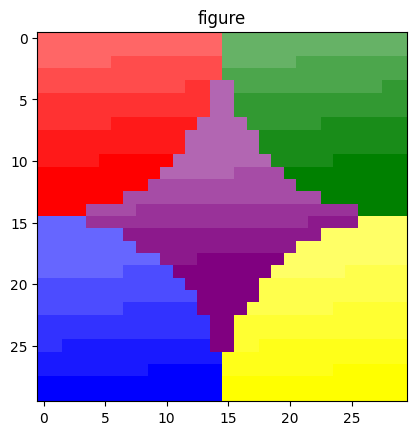

In [5]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

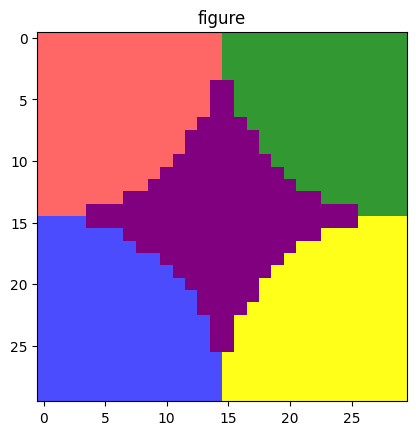

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

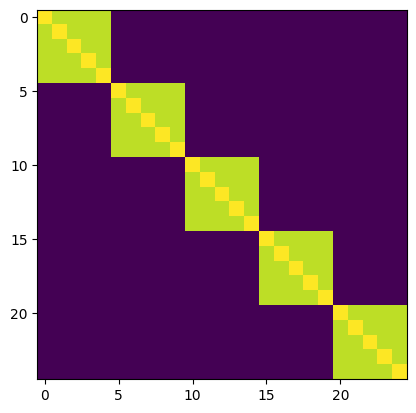

In [7]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.45)
plt.imshow(R)


covariance across tasks G

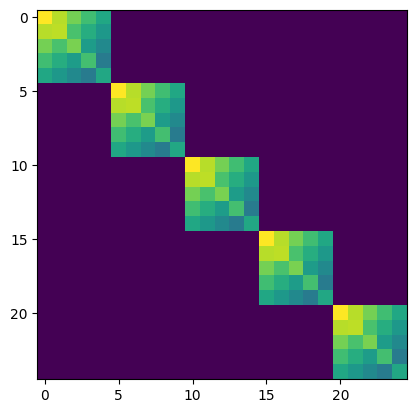

In [8]:
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=[1,0.9,0.8,0.7,0.6])
plt.imshow(G)

make Vs (this num_iter gives a good V)

17.613652168263002
15.202629408012863
15.171034613279941
14.651788280270802
14.550428466507402
14.271245668305681
14.268131317850955
14.194719035643718


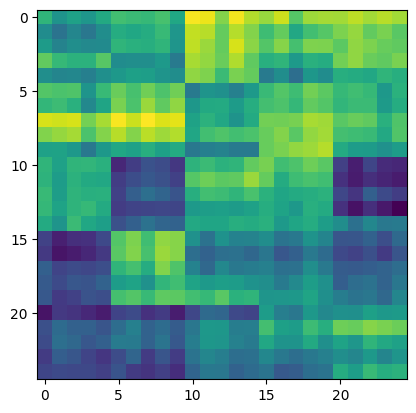

In [9]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

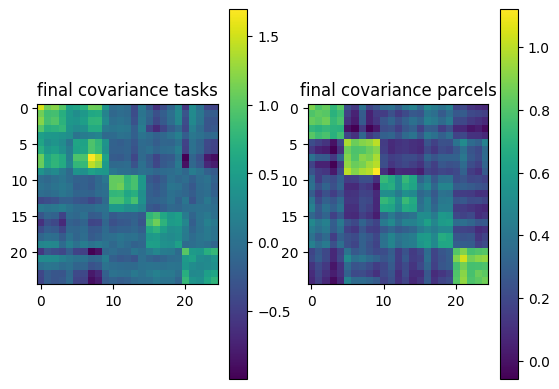

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

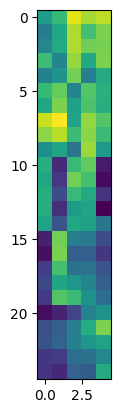

In [11]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [12]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

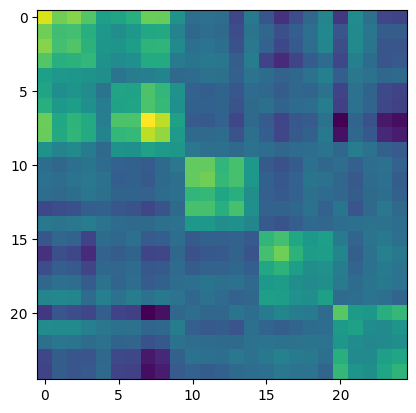

In [13]:
G_lib  = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [26]:
D = ut.build_combinations(G_lib, strategy='random',n_iter=50000,n_tasks=8,seed=600)
D_ev = ev.evaluate_dataframe_simulation_multiregion(D,Y_true, Vs_5, U_true_5,sig_e=0.15)



building0
building10000
building20000
building30000
building40000
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing combination: 10000
Processing combination: 11000
Processing combination: 12000
Processing combination: 13000
Processing combination: 14000
Processing combination: 15000
Processing combination: 16000
Processing combination: 17000
Processing combination: 18000
Processing combination: 19000
Processing combination: 20000
Processing combination: 21000
Processing combination: 22000
Processing combination: 23000
Processing combination: 24000
Processing combination: 25000
Processing combination: 26000
Processing combination: 27000
Processing combination: 28000
Processing combination: 29000
Processing combination: 30000
Processing combin

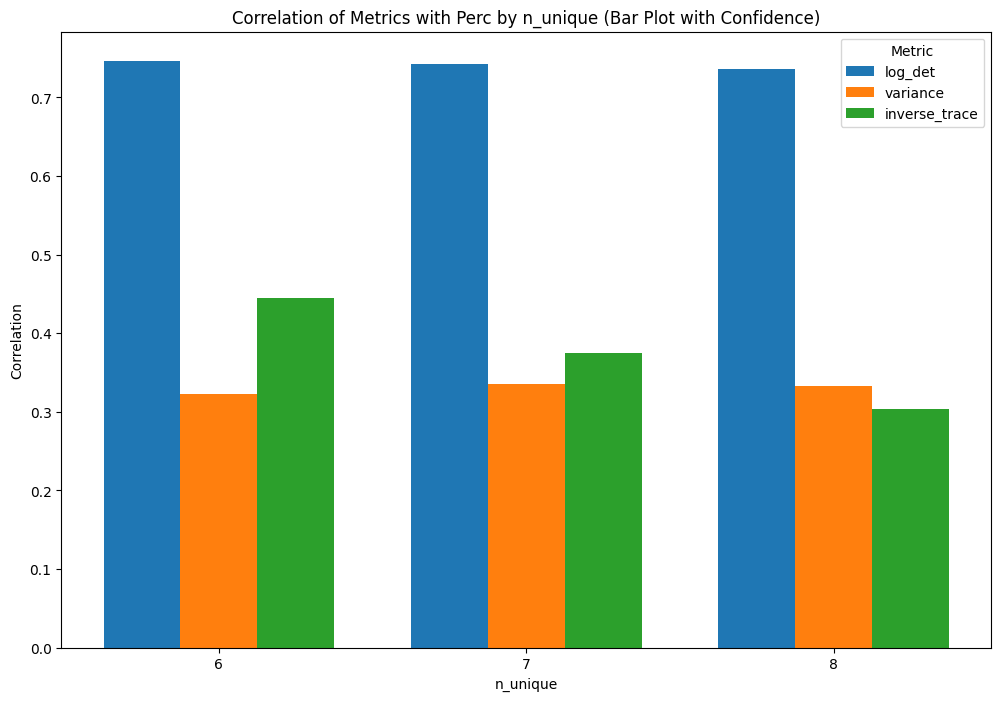

In [27]:
variables = ['log_det', 'variance', 'inverse_trace']
target_variable = 'perc'
n_samples = 10000

results = {'n_unique': [], 'variable': [], 'correlation': []}

n_unique_values = D_ev['n_unique'].unique()
sorte_n_unique_values = np.sort(n_unique_values)

for n_unique_val in sorte_n_unique_values:
    D_unique = D_ev[D_ev['n_unique'] == n_unique_val]
    if len(D_unique) < n_samples:
        continue
    D_unique = D_unique[:n_samples]

    for var in variables:
        correlation = np.corrcoef(D_unique[var], D_unique[target_variable])[0, 1]
        results['n_unique'].append(n_unique_val)
        results['variable'].append(var)
        results['correlation'].append(correlation)

results_df = pd.DataFrame(results)
plt.figure(figsize=(12, 8))
bar_width = 0.25  
unique_values = results_df['n_unique'].unique()
x_positions = np.arange(len(unique_values))

for i, var in enumerate(variables):
    subset = results_df[results_df['variable'] == var]
    plt.bar(
        x_positions + i * bar_width,
        subset['correlation'],
        capsize=5, 
        width=bar_width,
        label=var
    )

plt.title('Correlation of Metrics with Perc by n_unique (Bar Plot with Confidence)')
plt.xlabel('n_unique')
plt.ylabel('Correlation')
plt.xticks(ticks=x_positions + bar_width, labels=unique_values)
plt.legend(title='Metric')
plt.show()


# Build model

In [ ]:
X = D_ev[['variance', 'log_det','inverse_trace']]
y = D_ev['perc'].values

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_standardized = (X - X_mean) / X_std


ones = np.ones(shape=(X_standardized.shape[0], 1))
X_design = np.hstack([ones, X_standardized])
Betas = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
Betas
intercept = Betas[0]
coefficients = Betas[1:]
y_pred = X_design @ Betas

residuals = y - y_pred
SS_res = np.sum(residuals ** 2)
SS_tot = np.sum((y - y.mean()) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f'R^2: {R_squared}')

# Print the results
print("Intercept:", intercept)
print("Coefficients:")
for i, coef in enumerate(coefficients):
    print(f"{X.columns[i]}: {coef}")


R^2: 0.6588362538757708
Intercept: 71.57062577777779
Coefficients:
variance: -0.49975897043476614
log_det: 6.04364898512242
inverse_trace: -3.1715747208008387
n_unique: -0.3932610744025847


In [66]:
from scipy.linalg import block_diag

# Prepare variables
variables = ['variance', 'log_det', 'inverse_trace']
target_variable = 'perc'

# Get the unique groups
unique_groups = np.sort(D_ev['n_unique'].unique())

# Lists to collect group-specific data
design_matrices = []
response_vectors = []
group_feature_names = []

unique_groups_avaialble = []

for group_value in unique_groups:
    group_data = D_ev[D_ev['n_unique'] == group_value]

    if len(group_data) < 10000:
        continue
    unique_groups_avaialble.append(group_value)
    
    # sample from data so groups have equal size
    group_data = group_data.sample(n=10000, random_state=42)
    
    # X and Y for this group
    X_group = group_data[variables].values
    y_group = group_data[target_variable].values
    
    # Standardize to make it interpretable...
    X_mean = X_group.mean(axis=0)
    X_std = X_group.std(axis=0)
    X_standardized = (X_group - X_mean) / X_std
    
    # Add intercept 
    ones = np.ones((X_standardized.shape[0], 1))
    X_design_group = np.hstack([ones, X_standardized])
    
    # Collect design matrices and y vars
    design_matrices.append(X_design_group)
    response_vectors.append(y_group)
    
    # make names for the features
    feature_names = ['Intercept'] + [f"{var}_group_{group_value}" for var in variables]
    group_feature_names.append(feature_names)

# combine all design matrices
X_design_blocked = block_diag(*design_matrices)

# combine all response vectors
y_combined = np.concatenate(response_vectors)

# ols reg
Betas = np.linalg.inv(X_design_blocked.T @ X_design_blocked) @ X_design_blocked.T @ y_combined





In [70]:
# plt.imshow(X_design_blocked)

In [68]:
# Extract coefficients for each group
current_index = 0
group_betas = {}
for i, feature_names in enumerate(group_feature_names):
    num_features = len(feature_names)
    Betas_group = Betas[current_index:current_index + num_features]
    group_value = unique_groups_avaialble[i]
    group_betas[group_value] = Betas_group
    current_index += num_features

In [71]:
# Calculate R-squared
y_pred = X_design_blocked @ Betas
residuals = y_combined - y_pred
SS_res = np.sum(residuals ** 2)
SS_tot = np.sum((y_combined - y_combined.mean()) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"Overall R^2: {R_squared}")

Overall R^2: 0.6506550144605635


In [79]:
group_coefficients = {
    "Group": [],
    "Variable": [],
    "Coefficient": []
}

for group_value, Betas_group in group_betas.items():
    for name, coef in zip(group_feature_names[unique_groups_avaialble.index(group_value)], Betas_group):
        if "Intercept" not in name:
            var_name = name.split("_group_")[0]
            group_coefficients["Group"].append(group_value)
            group_coefficients["Variable"].append(var_name)
            group_coefficients["Coefficient"].append(coef)

coeff_df = pd.DataFrame(group_coefficients)

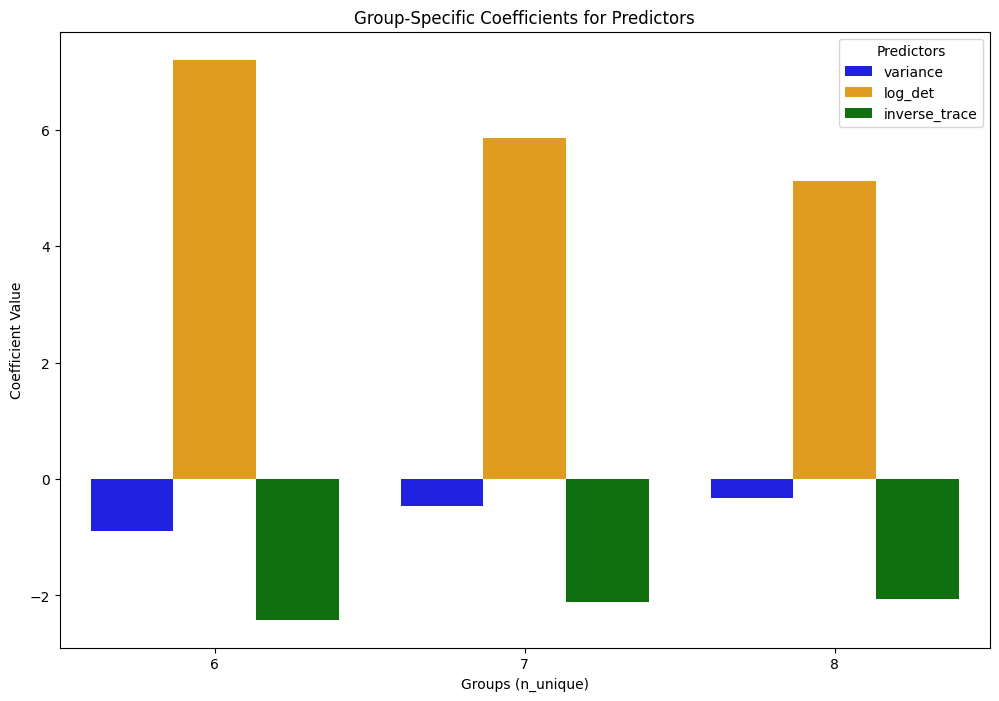

In [80]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=coeff_df,
    x="Group",
    y="Coefficient",
    hue="Variable",
    palette={"variance": "blue", "log_det": "orange", "inverse_trace": "green"}
)

plt.title("Group-Specific Coefficients for Predictors")
plt.xlabel("Groups (n_unique)")
plt.ylabel("Coefficient Value")
plt.legend(title="Predictors")
plt.show()